# EDA — Revisión de reclamos de un marketplace (datos sintéticos)

**Proyecto de portafolio.** Análisis exploratorio de una base **100% sintética** que simula la operación de revisión de reclamos de un marketplace/e-commerce en Latinoamérica, gestionados por un equipo de soporte.

> ⚠️ **Disclaimer:** los datos NO son reales. Fueron generados con Python/pandas/numpy para parecer realistas y permitir storytelling analítico sin exponer información sensible. No deben usarse para conclusiones del mundo real.

**Preguntas que responde este EDA:**
1. ¿Cómo se distribuyen los casos de alto riesgo y cómo evolucionan mes a mes?
2. ¿Qué tan bien gestionan los representantes y cómo varían entre sí?
3. ¿Se cumple el SLA y cómo se relaciona con la calidad de la gestión?
4. ¿Con qué frecuencia se aplican restricciones y qué proporción se revierte (rollback)?
5. ¿Hay patrones por país, producto, canal y estacionalidad?

## 1. Carga de datos y configuración

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
plt.rcParams.update({'figure.dpi':110, 'font.size':10})
C1, C2 = '#2E86AB', '#E4572E'   # azul / naranja

df = pd.read_csv('../data/casos.csv', encoding='utf-8-sig')
print('Filas:', f'{len(df):,}', '| Columnas:', df.shape[1])
df.head()

Filas: 204,656 | Columnas: 23


,id_caso,fecha_de_creacion_caso,fecha_asignacion,fecha_cierre,id_representante,flag_riesgo,decision,fuente,regla,tipo_reclamo,restriccion,tipo_restriccion,rollback_restriccion,producto_reclamado,valor_producto_usd,dias_recepcion_a_reclamo,sla_minutos,tiempo_gestion_horas,mes,semana,pais_region,canal_contacto,eficiencia
0,30VXZW5CBU,2025-01-01 00:07:01,2025-01-01 11:48:23.908626242,2025-01-01 11:55:05.908626242,zzamora,1,HIGH,CX,return_Producto_no_recibido,Producto_no_recibido,0,Sin restriccion,0,Laptop Lenovo,685.50,3,6.7,11.80,2025-01,2025-S01,Chile,Web,1
1,31U5B09W07,2025-01-01 00:13:50,2025-01-01 11:22:08.314998954,2025-01-01 11:27:20.314998954,zzamora,0,LOW,Sin mediacion,forward_Caja_vacia,Caja_vacia,0,Sin restriccion,0,Silla gamer,313.23,10,5.2,11.23,2025-01,2025-S01,Brasil,Chat,1
2,02835Q6KUU,2025-01-01 00:21:09,2025-01-01 10:27:07.685752942,2025-01-01 10:34:55.685752942,uuribe,1,HIGH,CX,return_Producto_diferente_defectuoso,Producto_diferente_defectuoso,0,Sin restriccion,0,Nevera,1006.47,37,7.8,10.23,2025-01,2025-S01,Brasil,App movil,1
3,3G8KRV5LPD,2025-01-01 00:27:25,2025-01-01 10:48:22.579787950,2025-01-01 10:55:10.579787950,wwong,0,LOW,CX,return_Producto_no_recibido,Producto_no_recibido,0,Sin restriccion,0,Aire acondicionado,645.17,13,6.8,10.46,2025-01,2025-S01,Brasil,App movil,1
4,04HG9QR5GK,2025-01-01 00:34:56,2025-01-01 10:56:57.472388637,2025-01-01 11:06:09.472388637,uuribe,0,LOW,CX,forward_Producto_no_recibido,Producto_no_recibido,0,Sin restriccion,0,Aire acondicionado,689.07,23,9.2,10.52,2025-01,2025-S01,Argentina,Chat,1


In [2]:
# Dimensiones del modelo estrella
dims = pd.read_excel('../data/gestion_operativa.xlsx', sheet_name=None)
print('Hojas de dimensiones:', list(dims.keys()))

Hojas de dimensiones: ['dim_representante', 'dim_calendario', 'dim_pais', 'dim_producto', 'dim_tipo_reclamo', 'dim_tipo_restriccion', 'dim_canal']


## 2. Validaciones de integridad

In [3]:
print('Nulos totales:', int(df.isna().sum().sum()))
print('IDs de caso duplicados:', int(df.id_caso.duplicated().sum()))
print('Representantes:', df.id_representante.nunique())
print('Países:', df.pais_region.nunique(), '| Productos:', df.producto_reclamado.nunique(), '| Canales:', df.canal_contacto.nunique())
print('Rango temporal:', df.mes.min(), '->', df.mes.max())
# Coherencia decision <-> flag_riesgo
print('decision espejo de flag_riesgo:', bool(((df.decision=='HIGH')==(df.flag_riesgo==1)).all()))
# Rollback solo si hubo restricción
print('Rollbacks sin restricción (debe ser 0):', int(((df.rollback_restriccion==1)&(df.restriccion==0)).sum()))

Nulos totales: 0
IDs de caso duplicados: 0
Representantes: 32
Países: 9 | Productos: 26 | Canales: 5
Rango temporal: 2025-01 -> 2025-08
decision espejo de flag_riesgo: True
Rollbacks sin restricción (debe ser 0): 0


## 3. KPIs operativos globales

In [4]:
kpis = {
 'Casos totales': len(df),
 '% Alto riesgo (HIGH)': (df.decision=='HIGH').mean()*100,
 '% Buena gestión (eficiencia=1)': df.eficiencia.mean()*100,
 '% con restricción aplicada': df.restriccion.mean()*100,
 'SLA promedio (min)': df.sla_minutos.mean(),
 'Valor reclamado total (M USD)': df.valor_producto_usd.sum()/1e6,
}
for k,v in kpis.items(): print(f'{k:35s}: {v:,.2f}')

Casos totales                      : 204,656.00
% Alto riesgo (HIGH)               : 33.93
% Buena gestión (eficiencia=1)     : 88.75
% con restricción aplicada         : 26.73
SLA promedio (min)                 : 9.34
Valor reclamado total (M USD)      : 117.21


### Conclusión KPIs
La operación procesa **~205k casos** con **88,7% de buena gestión** (sobre un objetivo del 85%). El **34%** de los casos se marca de alto riesgo y en **~27%** se aplica una restricción a la cuenta.

## 4. Riesgo: distribución y evolución mensual

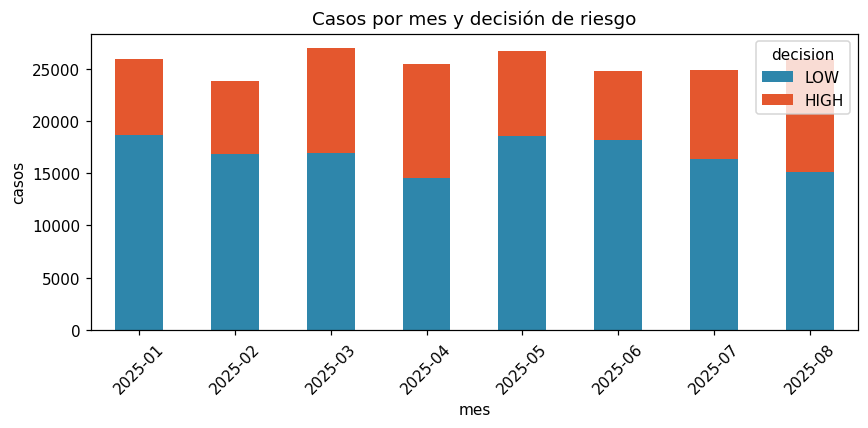

% HIGH global: 33.93


In [5]:
ct = pd.crosstab(df.mes, df.decision)
ax = ct[['LOW','HIGH']].plot(kind='bar', stacked=True, color=[C1,C2], figsize=(8,4))
ax.set_title('Casos por mes y decisión de riesgo'); ax.set_ylabel('casos'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()
print('% HIGH global:', round((df.decision=='HIGH').mean()*100,2))

## 5. Calidad de gestión: tendencia mensual de errores

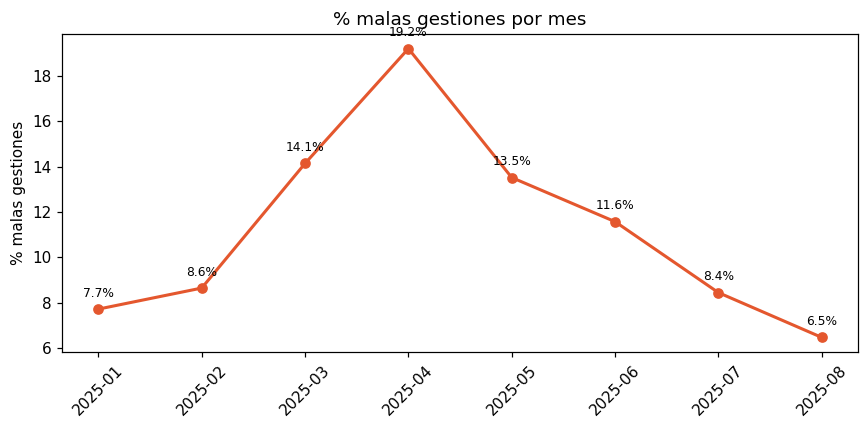

mes
2025-01     7.71
2025-02     8.64
2025-03    14.14
2025-04    19.21
2025-05    13.51
2025-06    11.57
2025-07     8.43
2025-08     6.46
Name: eficiencia, dtype: float64

In [6]:
err_mes = df.groupby('mes').eficiencia.apply(lambda s:(1-s.mean())*100)
plt.figure(figsize=(8,4)); plt.plot(err_mes.index, err_mes.values, marker='o', color=C2, lw=2)
for x,y in zip(err_mes.index, err_mes.values): plt.annotate(f'{y:.1f}%',(x,y),textcoords='offset points',xytext=(0,8),ha='center',fontsize=8)
plt.title('% malas gestiones por mes'); plt.ylabel('% malas gestiones'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()
err_mes.round(2)

### Conclusión tendencia
Los errores **escalan hasta abril (19,2% — mes crítico)** y luego **bajan de forma sostenida hasta agosto (6,5%)**. Es el patrón temporal central para narrar el proyecto: hubo un deterioro y una recuperación.

## 6. Variación entre representantes

,casos,pct_error,sla_prom
id_representante,,,
llopez,5792,3.94,14.76
xximenez,4040,5.59,9.38
nnunez,3160,6.14,5.71


,casos,pct_error,sla_prom
id_representante,,,
ffranco,6216,18.11,11.24
qquiroz,4792,19.26,8.04
ttorres,4064,30.46,10.49


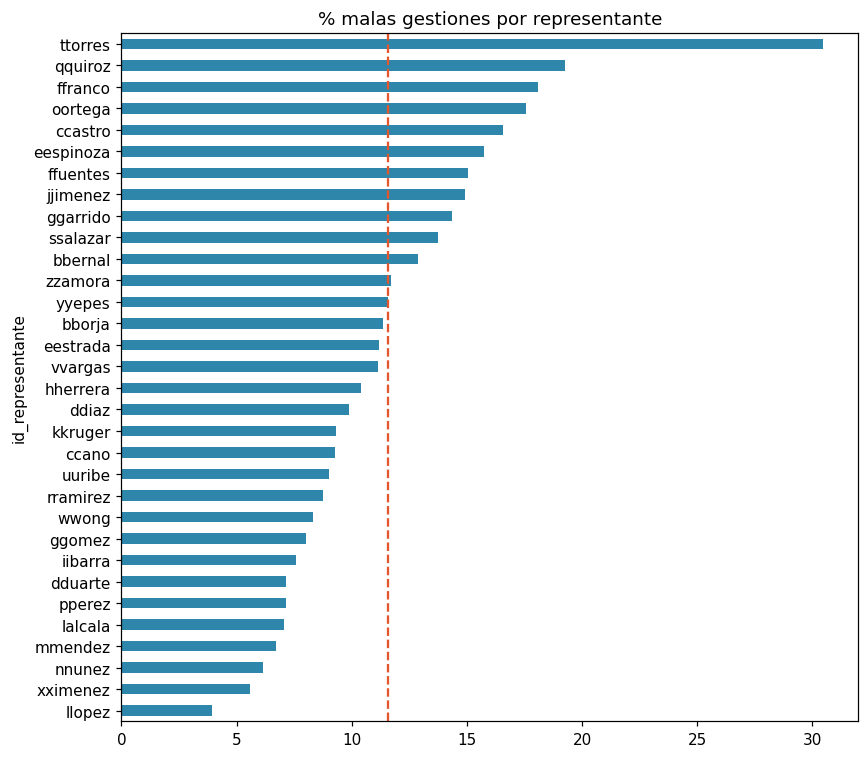

In [7]:
g = df.groupby('id_representante').agg(
    casos=('id_caso','count'),
    pct_error=('eficiencia', lambda s:(1-s.mean())*100),
    sla_prom=('sla_minutos','mean')).round(2)
g = g.sort_values('pct_error')
display(g.head(3)); display(g.tail(3))
g.pct_error.sort_values().plot(kind='barh', figsize=(8,7), color=C1, title='% malas gestiones por representante')
plt.axvline(g.pct_error.mean(), ls='--', color=C2); plt.tight_layout(); plt.show()

### Conclusión representantes
La calidad varía mucho entre personas: del **~4% de error (mejor, `llopez`)** al **~30% (peor, `ttorres`)**. Hay una oportunidad clara de coaching focalizado.

## 7. SLA vs calidad — el hallazgo clave

In [8]:
df['sla_extremo'] = ((df.sla_minutos<=3)|(df.sla_minutos>=18)).astype(int)
print(pd.crosstab(df.sla_extremo, df.eficiencia, rownames=['SLA extremo'], colnames=['eficiencia']))
print('\nTodos los SLA extremos son mala gestión:',
      bool((df[df.sla_extremo==1].eficiencia==0).all()))
print('Todas las malas gestiones son SLA extremo:',
      bool((df[df.eficiencia==0].sla_extremo==1).all()))

eficiencia       0       1
SLA extremo               
0                0  181629
1            23027       0

Todos los SLA extremos son mala gestión: True
Todas las malas gestiones son SLA extremo: True


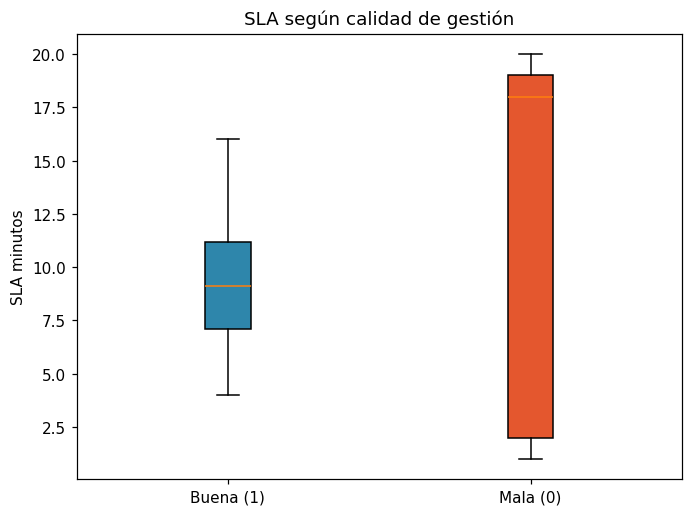

In [9]:
data=[df[df.eficiencia==1].sla_minutos, df[df.eficiencia==0].sla_minutos]
bp=plt.boxplot(data, tick_labels=['Buena (1)','Mala (0)'], patch_artist=True, showfliers=False)
for p,c in zip(bp['boxes'],[C1,C2]): p.set_facecolor(c)
plt.title('SLA según calidad de gestión'); plt.ylabel('SLA minutos'); plt.tight_layout(); plt.show()

### Conclusión SLA
Existe **correspondencia exacta**: una gestión es mala **si y solo si** el SLA es extremo — demasiado rápida (**≤3 min**, gestión apresurada) o demasiado lenta (**≥18 min**). El SLA medio sano ronda los **9,3 min**. El SLA es, por diseño, el driver de la calidad.

## 8. Restricciones y rollback por representante

Restricciones aplicadas: 54,713 | Revertidas: 4,494
Rollback global: 8.21 %


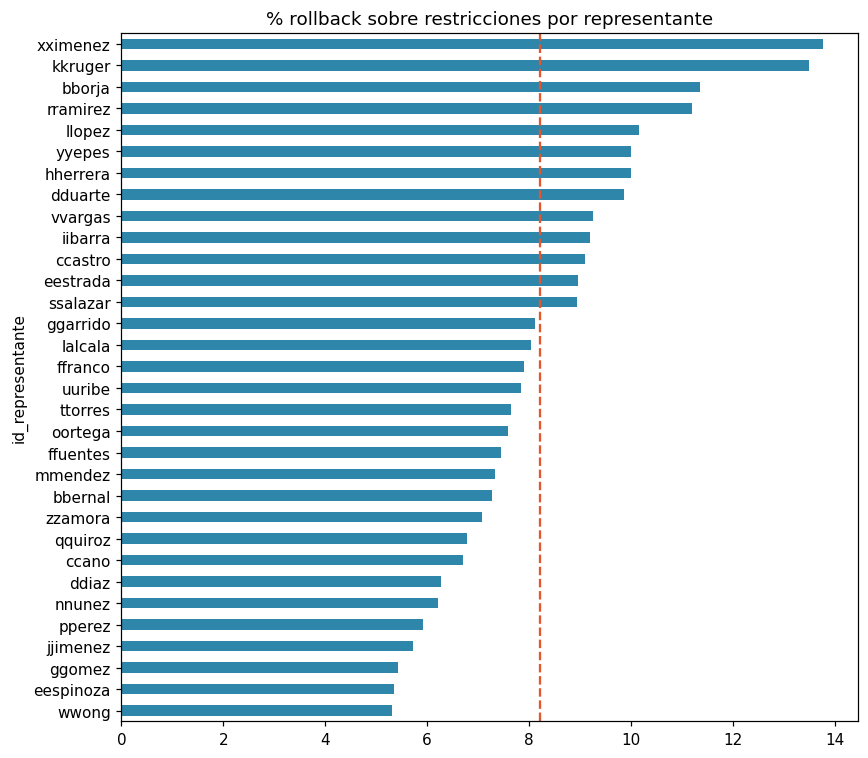

Rango por rep: 5.31 % a 13.76 %


In [10]:
rest = df[df.restriccion==1]
print('Restricciones aplicadas:', f'{len(rest):,}', '| Revertidas:', f'{int(rest.rollback_restriccion.sum()):,}')
print('Rollback global:', round(rest.rollback_restriccion.mean()*100,2), '%')
rb = (rest.groupby('id_representante').rollback_restriccion.mean()*100).sort_values()
rb.plot(kind='barh', figsize=(8,7), color=C1, title='% rollback sobre restricciones por representante')
plt.axvline(8.21, ls='--', color=C2); plt.tight_layout(); plt.show()
print('Rango por rep:', round(rb.min(),2),'% a', round(rb.max(),2),'%')

### Conclusión rollback
De las restricciones aplicadas se revierte un **8,2% global**, con un rango por representante de **5,3% a 13,8%**. Un rollback alto sugiere restricciones aplicadas con poco criterio.

## 9. Tipo de reclamo (desbalanceado)

In [11]:
tr = df.tipo_reclamo.value_counts(normalize=True)*100
tr.round(2)

tipo_reclamo
Producto_no_recibido             33.69
Producto_diferente_defectuoso    27.27
Devolucion                       22.62
Caja_vacia                       16.42
Name: proportion, dtype: float64

El mix está dominado por **Producto no recibido (~34%)**, seguido de Producto diferente/defectuoso (~27%), Devolución (~23%) y Caja vacía (~16%).

## 10. Patrones por país, producto y canal

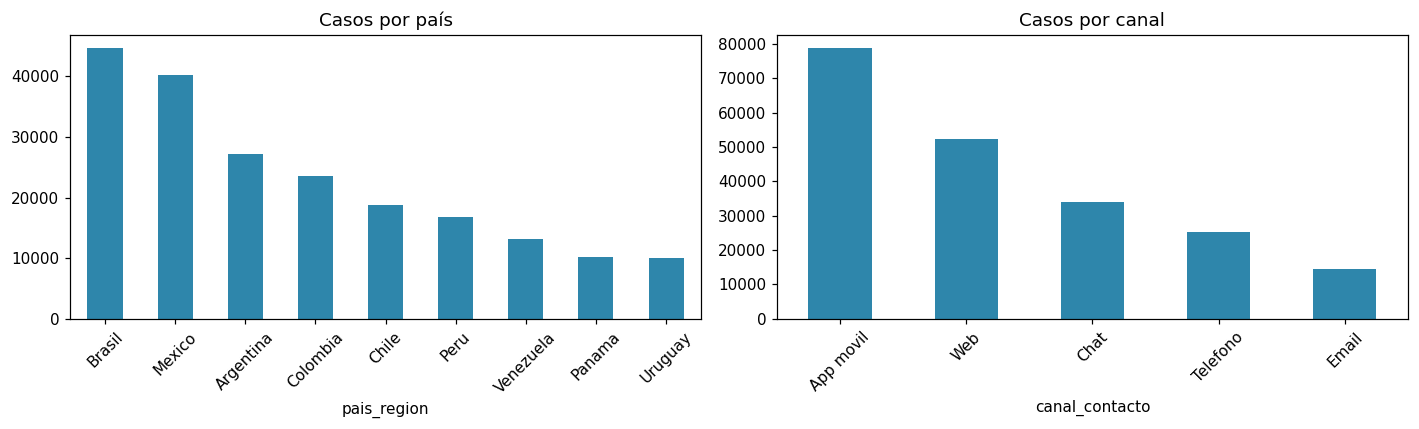

In [12]:
fig,ax=plt.subplots(1,2,figsize=(13,4))
df.pais_region.value_counts().plot(kind='bar', ax=ax[0], color=C1, title='Casos por país')
df.canal_contacto.value_counts().plot(kind='bar', ax=ax[1], color=C1, title='Casos por canal')
for a in ax: a.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

In [13]:
# SLA por canal y por tipo de reclamo
print('SLA promedio por canal:'); print(df.groupby('canal_contacto').sla_minutos.mean().round(2).sort_values(ascending=False))
print('\nSLA promedio por tipo de reclamo:'); print(df.groupby('tipo_reclamo').sla_minutos.mean().round(2).sort_values(ascending=False))

SLA promedio por canal:


canal_contacto
Telefono     10.87
Web           9.15
App movil     9.13
Email         9.12
Chat          9.09
Name: sla_minutos, dtype: float64

SLA promedio por tipo de reclamo:
tipo_reclamo
Devolucion                       9.41
Caja_vacia                       9.39
Producto_diferente_defectuoso    9.33
Producto_no_recibido             9.29
Name: sla_minutos, dtype: float64


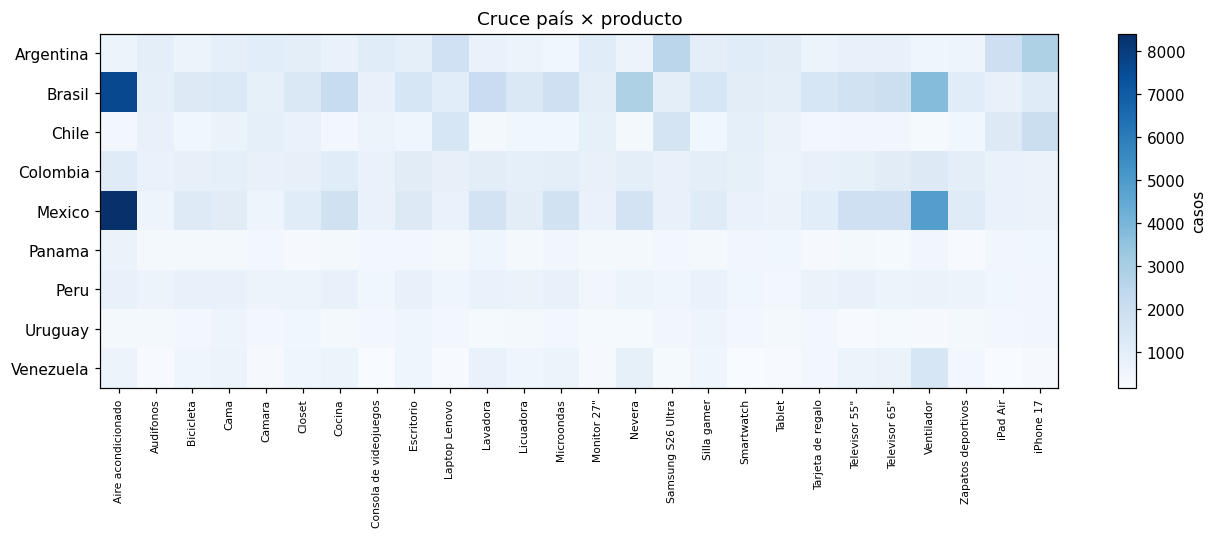

In [14]:
# Heatmap país x producto
pt = pd.crosstab(df.pais_region, df.producto_reclamado)
plt.figure(figsize=(12,5)); plt.imshow(pt.values, aspect='auto', cmap='Blues')
plt.yticks(range(len(pt.index)), pt.index); plt.xticks(range(len(pt.columns)), pt.columns, rotation=90, fontsize=7)
plt.colorbar(label='casos'); plt.title('Cruce país × producto'); plt.tight_layout(); plt.show()

## 11. Conclusiones generales

1. **Calidad sólida pero mejorable:** 88,7% de buena gestión, por encima del objetivo (85%), pero con fuerte dispersión entre representantes (4%–30% de error).
2. **El SLA es el termómetro de la calidad:** la mala gestión equivale exactamente a un SLA extremo (apresurado ≤3 min o lento ≥18 min). Vigilar los extremos del SLA permitiría anticipar errores.
3. **Patrón temporal claro:** deterioro hasta abril (19,2%) y recuperación hasta agosto (6,5%) — útil para evaluar el efecto de intervenciones.
4. **Restricciones con margen de afinación:** 8,2% de rollback global, hasta 13,8% en algún representante.
5. **Mix de reclamos y geografía coherentes:** "producto no recibido" domina; los cruces país×producto y SLA por canal reflejan patrones realistas.

> Recordatorio final: **dataset sintético**. El valor del proyecto está en el método (generación de datos, modelado dimensional, análisis y narrativa), no en los datos en sí.